In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from nba_api.stats.static import players

players.find_players_by_full_name('Kobe Bryant')

[{'id': 977,
  'full_name': 'Kobe Bryant',
  'first_name': 'Kobe',
  'last_name': 'Bryant',
  'is_active': False}]

In [20]:
# pip install nba_api
from nba_api.stats.endpoints import shotchartdetail
import pandas as pd

# Example: Stephen Curry in the 2023-24 season
response = shotchartdetail.ShotChartDetail(
    team_id=0,                       # 0 = all teams
    player_id=201939,               # Stephen Curry's ID
    season_type_all_star='Regular Season',
    season_nullable='2023-24',
    context_measure_simple='FGA',  # Field Goal Attempts
)

# Convert to DataFrame
df = response.get_data_frames()[0]
# print(df[['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_FLAG']].head())


In [161]:
(df['SHOT_TYPE'].unique())

array(['3PT Field Goal', '2PT Field Goal'], dtype=object)

In [164]:
df['POINTS'] = df.apply(lambda x: 3*x['SHOT_MADE_FLAG'] if x['SHOT_TYPE'][0] == '3' else 2*x['SHOT_MADE_FLAG'], axis = 1)

In [165]:
df

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,POINTS
0,Shot Chart Detail,0022300005,40,201939,Stephen Curry,1610612744,Golden State Warriors,1,8,17,...,24+ ft.,24,-188,153,1,0,20231103,OKC,GSW,0
1,Shot Chart Detail,0022300005,53,201939,Stephen Curry,1610612744,Golden State Warriors,1,7,0,...,24+ ft.,28,145,243,1,1,20231103,OKC,GSW,3
2,Shot Chart Detail,0022300005,249,201939,Stephen Curry,1610612744,Golden State Warriors,2,6,15,...,24+ ft.,27,50,272,1,1,20231103,OKC,GSW,3
3,Shot Chart Detail,0022300005,281,201939,Stephen Curry,1610612744,Golden State Warriors,2,3,23,...,Less Than 8 ft.,4,-45,0,1,0,20231103,OKC,GSW,0
4,Shot Chart Detail,0022300005,292,201939,Stephen Curry,1610612744,Golden State Warriors,2,2,29,...,24+ ft.,24,230,83,1,1,20231103,OKC,GSW,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440,Shot Chart Detail,0022301222,685,201939,Stephen Curry,1610612744,Golden State Warriors,4,0,19,...,24+ ft.,27,129,243,1,1,20231208,OKC,GSW,3
1441,Shot Chart Detail,0022301222,702,201939,Stephen Curry,1610612744,Golden State Warriors,4,0,0,...,24+ ft.,29,-4,290,1,0,20231208,OKC,GSW,0
1442,Shot Chart Detail,0022301222,727,201939,Stephen Curry,1610612744,Golden State Warriors,5,3,57,...,24+ ft.,29,1,294,1,1,20231208,OKC,GSW,3
1443,Shot Chart Detail,0022301222,742,201939,Stephen Curry,1610612744,Golden State Warriors,5,2,27,...,8-16 ft.,15,70,142,1,1,20231208,OKC,GSW,2


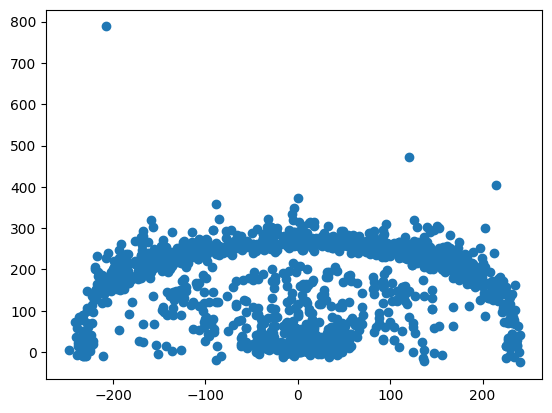

In [ ]:
plt.scatter(df['LOC_X'], df['LOC_Y'], color = )
plt.show()

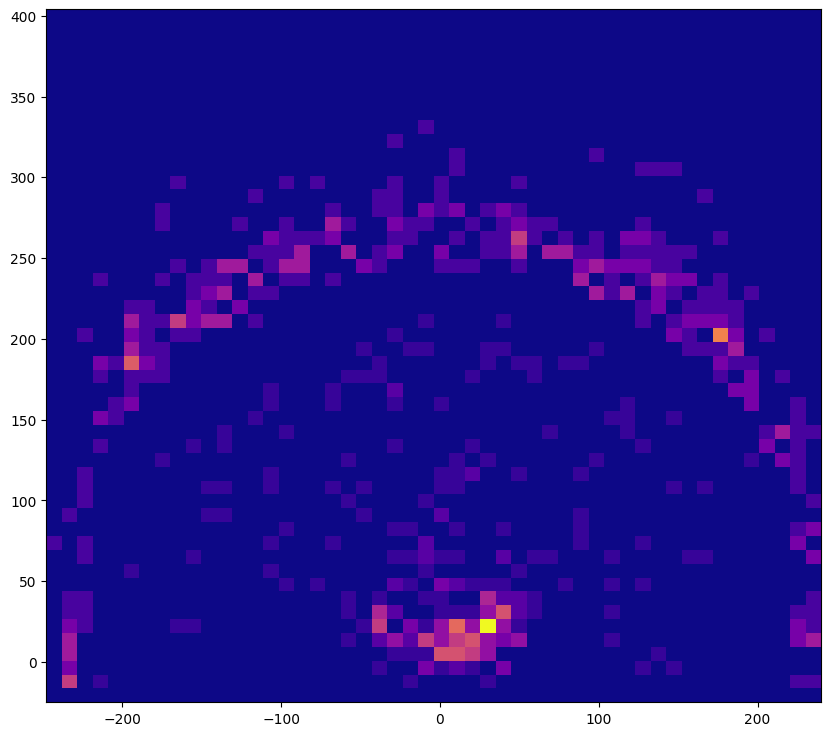

In [169]:
# shots = df.drop(df['LOC_Y'].idxmax()).sample(1000)
shots = df[df['LOC_Y'] < 450]
x = shots['LOC_X']
y = shots['LOC_Y']

x_bins = 50
y_bins = 50

# Create 2D histogram
plt.figure(figsize=(10, 9))
plt.hist2d(x, y, weights = shots['POINTS'], bins=[x_bins, y_bins], cmap='plasma')
# plt.gca().set_aspect('equal')
plt.show()

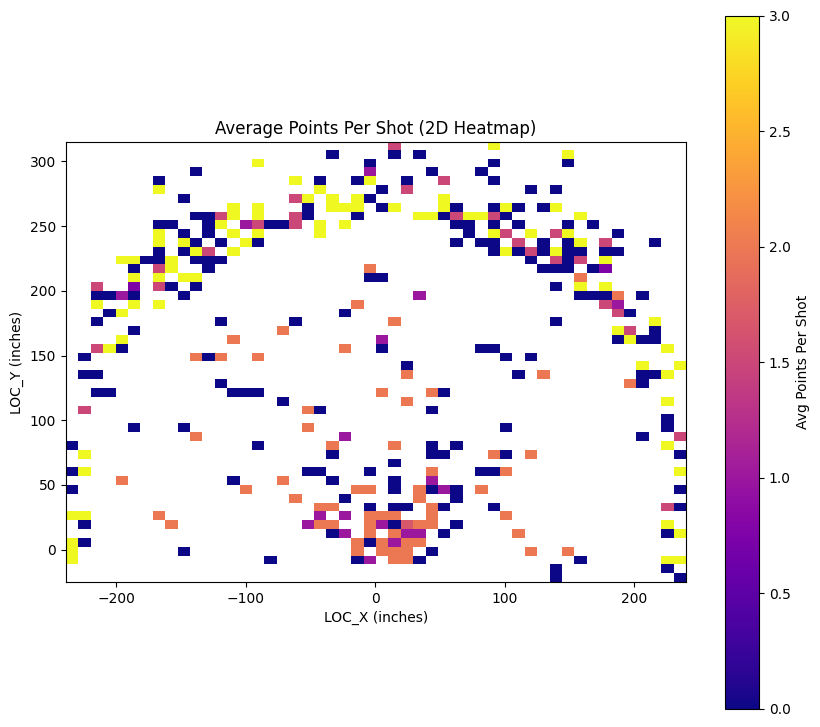

In [173]:
shots = df[df['LOC_Y'] < 450].sample(500)
plt.figure(figsize=(10, 9))
hb = plt.hist2d(
    x=shots['LOC_X'],
    y=shots['LOC_Y'],
    bins=[50, 50],  # grid resolution
    weights=shots['POINTS'],  # sum of points in each bin
    cmap='viridis',
    cmin=0
)

# Divide sum of points by number of shots per bin to get avg points per shot
counts, _, _ = np.histogram2d(shots['LOC_X'], shots['LOC_Y'], bins=hb[1:3])
average_points = hb[0] / np.where(counts == 0, np.nan, counts)  # avoid div by 0

# Plot average points per shot as heatmap
plt.clf()  # clear the previous plot
plt.imshow(
    np.flipud(average_points.T),
    extent=[hb[1][0], hb[1][-1], hb[2][0], hb[2][-1]],
    cmap='plasma',
    interpolation='nearest',
    aspect='equal'
)
plt.colorbar(label='Avg Points Per Shot')
plt.title("Average Points Per Shot (2D Heatmap)")
plt.xlabel("LOC_X (inches)")
plt.ylabel("LOC_Y (inches)")
plt.gca().set_aspect('equal')
plt.show()

In [4]:
# box = pd.read_csv('data/boxscore.csv')
# game = pd.read_csv('data/games.csv')[['seasonStartYear', 'pointsAway', 'game_id']]

In [5]:
# players = ['Stephen Curry', 'Shai Gilgeous-Alexander', 'Giannis Antetokounmpo', 'LeBron James', 'Rudy Gobert',\
# 'Shaquille O\'Neal', 'DeAndre Jordan', 'Ben Wallace']
# df = box[box['playerName'].isin(players)]
# df = df.merge(game, on = 'game_id')
# df = df[df['MP'] != 'Did Not Play']
# df['+/-'] = df['+/-'].str.strip('+').apply(pd.to_numeric, errors='coerce')
# df['seasonStartYear'] = df['seasonStartYear'].astype(str)
# df[['FG', 'FGA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']] = df[['FG', 'FGA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']].apply(pd.to_numeric, errors='coerce')


In [ ]:
# totals = df.groupby(['playerName', 'seasonStartYear'])[['FT', 'FTA']].sum().reset_index()
# totals['FT%'] = totals['FT'] / totals['FTA']
# totals.sort_values('FT%', ascending=False)
# for player, color in [('Stephen Curry', 'green'), ('DeAndre Jordan', 'red')]:
#     fig = totals[totals['playerName'] == player].plot(kind = 'line', x = 'seasonStartYear', y = 'FT%', title = f'{player} FT%', color = color)
#     fig.set_ylim(.3, 1)

In [ ]:
# df.plot(kind = 'scatter', x = 'FT', y = '+/-', title = 'Effect of FT Made on Player Impact')
# df.plot(kind = 'scatter', x = 'FTA', y = '+/-', title = 'Effect of FT Attempts on Player Impact')

In [ ]:
# totals = df.groupby('playerName')[['PTS', 'FT']].sum().reset_index()
# totals['proportion'] = (round((totals['FT'] / totals['PTS']) * 100, 2))#.apply(str) + '%'
# totals

# # Assuming 'totals' is a DataFrame already defined
# ax = (
#     totals.sort_values('PTS', ascending=False)
#     .plot(
#         kind='bar',
#         x='playerName',
#         y=['FT', 'PTS'],
#         stacked=True,
#         figsize=(12, 6),  # Adjust figure size
#         title='Free Throw Points vs Total Points'  # Clearer Title
#     )
# )

# # Customizing the Legend
# ax.legend(['Free Throw Points', 'Total Points'])

# # Customizing Labels and Rotation
# ax.set_xlabel('Player Name')
# ax.set_ylabel('Points')
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Displaying the Plot
# plt.tight_layout()
# plt.show()
